In [2]:
# 🖼️ Redimensionador de Imágenes

#Reduce el tamaño de imágenes de `fotosparareducir/` a **256×256 píxeles** y guarda los resultados en `fotosreducidas/`

#**Beneficios:**
#- Reduce peso de archivos
#- Acelera entrenamiento del modelo
#- Mantiene información suficiente para clasificación de frutas

In [3]:
%pip install -q pillow opencv-python
from pathlib import Path
import cv2
from PIL import Image
import os

print('✅ Librerías cargadas')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Librerías cargadas


In [4]:
# Configuración
INPUT_DIR = Path('fotosparareducir')
OUTPUT_DIR = Path('fotosreducidas')
TARGET_SIZE = (256, 256)

# Crear directorio de salida
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'📁 Entrada: {INPUT_DIR}')
print(f'📁 Salida: {OUTPUT_DIR}')
print(f'📐 Tamaño objetivo: {TARGET_SIZE[0]}×{TARGET_SIZE[1]} píxeles')

📁 Entrada: fotosparareducir
📁 Salida: fotosreducidas
📐 Tamaño objetivo: 256×256 píxeles


In [5]:
# Procesar imágenes
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}
image_files = sorted([f for f in INPUT_DIR.rglob('*') if f.suffix.lower() in IMAGE_EXTENSIONS])

print(f'📷 Imágenes encontradas: {len(image_files)}')
print('-' * 60)

total_processed = 0
total_size_before = 0
total_size_after = 0

def resize_without_distortion(image, target_size, bg_color=(255, 255, 255)):
    """
    Redimensiona imagen manteniendo aspect ratio sin distorsión.
    Agrega padding (franjas blancas) si es necesario.
    """
    # Obtener dimensiones originales
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height
    
    # Calcular nuevo tamaño manteniendo aspect ratio
    target_width, target_height = target_size
    
    if aspect_ratio > 1:  # Más ancho que alto
        new_width = target_width
        new_height = int(target_width / aspect_ratio)
    else:  # Más alto que ancho
        new_height = target_height
        new_width = int(target_height * aspect_ratio)
    
    # Redimensionar la imagen
    image_resized = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # Crear imagen cuadrada con fondo blanco
    final_image = Image.new('RGB', target_size, bg_color)
    
    # Calcular posición para centrar la imagen
    offset_x = (target_width - new_width) // 2
    offset_y = (target_height - new_height) // 2
    
    # Pegar la imagen redimensionada en el centro
    final_image.paste(image_resized, (offset_x, offset_y))
    
    return final_image

for img_path in image_files:
    try:
        # Leer imagen
        img = Image.open(img_path)
        
        # Convertir a RGB si es necesario
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Obtener tamaño original
        original_size = os.path.getsize(img_path)
        total_size_before += original_size
        
        # Redimensionar sin distorsión
        img_resized = resize_without_distortion(img, TARGET_SIZE, bg_color=(255, 255, 255))
        
        # Guardar en carpeta de salida
        output_path = OUTPUT_DIR / img_path.name
        img_resized.save(output_path, quality=95)
        
        # Obtener tamaño nuevo
        new_size = os.path.getsize(output_path)
        total_size_after += new_size
        
        # Porcentaje de reducción
        reduction = ((original_size - new_size) / original_size) * 100
        
        print(f'✓ {img_path.name}')
        print(f'  Original: {img.size[0]}×{img.size[1]}px → {original_size/1024:.1f}KB')
        print(f'  Reducida: 256×256px → {new_size/1024:.1f}KB ({reduction:.1f}%)')
        
        total_processed += 1
        
    except Exception as e:
        print(f'✗ Error en {img_path.name}: {e}')

print('-' * 60)
print(f'✅ Proceso completado')
print(f'📊 Imágenes procesadas: {total_processed}')
print(f'📦 Tamaño total antes: {total_size_before/(1024*1024):.2f} MB')
print(f'📦 Tamaño total después: {total_size_after/(1024*1024):.2f} MB')
if total_size_before > 0:
    total_reduction = ((total_size_before - total_size_after) / total_size_before) * 100
    print(f'📉 Reducción total: {total_reduction:.1f}%')

📷 Imágenes encontradas: 95
------------------------------------------------------------
✓ 20260527_195201.jpg
  Original: 2992×2992px → 1550.7KB
  Reducida: 256×256px → 20.5KB (98.7%)
✓ 20260527_195204.jpg
  Original: 2992×2992px → 1480.6KB
  Reducida: 256×256px → 18.3KB (98.8%)
✓ 20260527_195206.jpg
  Original: 2992×2992px → 1543.4KB
  Reducida: 256×256px → 19.2KB (98.8%)
✓ 20260527_195208.jpg
  Original: 2992×2992px → 1756.6KB
  Reducida: 256×256px → 18.5KB (98.9%)
✓ 20260527_195210.jpg
  Original: 2992×2992px → 1902.9KB
  Reducida: 256×256px → 18.6KB (99.0%)
✓ 20260527_195211.jpg
  Original: 2992×2992px → 1734.2KB
  Reducida: 256×256px → 18.5KB (98.9%)
✓ 20260527_195212.jpg
  Original: 2992×2992px → 1565.8KB
  Reducida: 256×256px → 18.1KB (98.8%)
✓ 20260527_195214.jpg
  Original: 2992×2992px → 1806.6KB
  Reducida: 256×256px → 17.5KB (99.0%)
✓ 20260527_195216.jpg
  Original: 2992×2992px → 1616.0KB
  Reducida: 256×256px → 19.3KB (98.8%)
✓ 20260527_195218.jpg
  Original: 2992×2992px → 

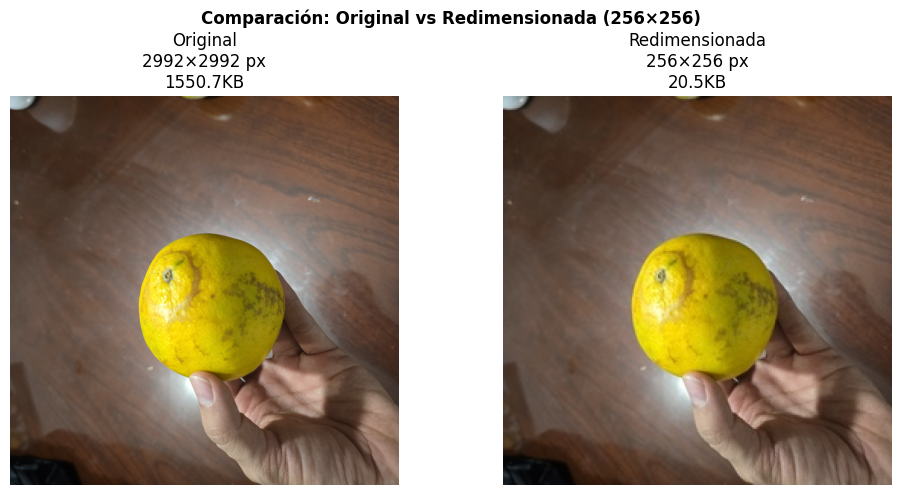

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Mostrar ejemplo de comparación (si hay imágenes)
output_files = list(OUTPUT_DIR.glob('*.jpg')) + list(OUTPUT_DIR.glob('*.png'))

if output_files and image_files:
    # Tomar la primera imagen
    sample_original = image_files[0]
    sample_reduced = OUTPUT_DIR / sample_original.name
    
    if sample_reduced.exists():
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle('Comparación: Original vs Redimensionada (256×256)', fontsize=12, fontweight='bold')
        
        # Original
        orig_img = Image.open(sample_original)
        axes[0].imshow(orig_img)
        axes[0].set_title(f'Original\n{orig_img.width}×{orig_img.height} px\n{os.path.getsize(sample_original)/1024:.1f}KB')
        axes[0].axis('off')
        
        # Redimensionada
        reduced_img = Image.open(sample_reduced)
        axes[1].imshow(reduced_img)
        axes[1].set_title(f'Redimensionada\n{reduced_img.width}×{reduced_img.height} px\n{os.path.getsize(sample_reduced)/1024:.1f}KB')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print('⚠️ No hay imágenes procesadas aún. Ejecuta la celda anterior primero.')